In [5]:
import pandas as pd
import numpy as np
import datetime as dt

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

# Load in Data

* Range of data: 1/1/2022 to 3/22/2024
* Train/validation range: 1/1/2022 to 1/14/2023
    * 0.8/0.2 random train-validation split
* Test range: 1/15/2024-3/22/2024

In [6]:
data = pd.read_csv("data.csv")

In [7]:
train = data.loc[:71423]
train.head(3)

,Unnamed: 0,date,time,power,workday
0,0,2022-01-01,0.00,0.0,0
1,1,2022-01-01,0.25,0.0,0
2,2,2022-01-01,0.50,0.0,0


In [8]:
test = data.loc[71424:]
test.head(3)

,Unnamed: 0,date,time,power,workday
71424,71424,2024-01-15,0.00,-1.367699e-07,0
71425,71425,2024-01-15,0.25,-1.367699e-07,0
71426,71426,2024-01-15,0.50,-1.367699e-07,0


In [9]:
x_dim = 8

def get_X_y(df, lookahead):
    power = df['power'].to_numpy()
    workday = df['workday'].to_numpy()
    time = df['time'].to_numpy()
    
    power_chunks = [power[i:i+x_dim] for i in range(0, len(power) - lookahead, lookahead)]
    workday = [workday[i] for i in range(0, len(power) - lookahead, lookahead)]
    time = [time[i] for i in range(0, len(power) - lookahead, lookahead)]
    
    y = [power[i:i+lookahead] for i in range(lookahead, len(power), lookahead)]

    X = pd.DataFrame(data={"power" : power_chunks, "workday" : workday, "time" : time})
    y = pd.DataFrame(data={"power" : y})

    X = X.reset_index()
    y = y.reset_index()

    return X, y

In [10]:
LOOKAHEAD = 16

X_trainval, y_trainval = get_X_y(train, LOOKAHEAD)
X_test, y_test = get_X_y(test, LOOKAHEAD)

In [11]:
X_trainval

,index,power,workday,time
0,0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]",0,0.0
1,1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]",0,4.0
2,2,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]",0,8.0
3,3,"[6.45464873881048, 6.45464873881048, 6.4546487...",0,12.0
4,4,"[6.45464873881048, 6.45464873881048, 6.4546487...",0,16.0
...,...,...,...,...
4458,4458,"[-1.3676991272859598e-07, -1.3676991272859598e...",0,0.0
4459,4459,"[-1.3676991272859598e-07, -1.3676991272859598e...",0,4.0
4460,4460,"[-1.3676991272859598e-07, -1.3676991272859598e...",0,8.0
4461,4461,"[12.883666914338178, 6.510118229018552, 6.5101...",0,12.0


In [12]:
y_trainval

,index,power
0,0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,2,"[6.45464873881048, 6.45464873881048, 6.4546487..."
3,3,"[6.45464873881048, 6.45464873881048, 6.4546487..."
4,4,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
...,...,...
4458,4458,"[-1.3676991272859598e-07, -1.3676991272859598e..."
4459,4459,"[-1.3676991272859598e-07, -1.3676991272859598e..."
4460,4460,"[12.883666914338178, 6.510118229018552, 6.5101..."
4461,4461,"[-1.367699198340233e-07, -1.367699198340233e-0..."


# Tuning K with Validation Set

In [14]:
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.2, random_state=42)

mses = []
wmses = []

alpha = 0.2

for k in range(1, 21):
    models = {}
    for t in [0, 4, 8, 12, 16, 20]:
        for w in [0, 1]:
            knn_regressor = KNeighborsRegressor(n_neighbors=k, weights='distance')
            mask = (X_train['time'] == t) & (X_train['workday'] == w)
            X_input = X_train[mask]['power']  
            y_input = y_train[mask]['power']  
            X_input = np.array([i for i in X_input])
            y_input = np.array([i for i in y_input])
            knn_regressor.fit(X_input, y_input)
            models[(t, w)] = knn_regressor


    forecasts = []
    for index, row in X_val.iterrows():
        forecasts.append(models[(row['time'], row['workday'])].predict(np.array(row['power']).reshape(1, -1)))

    forecast = np.array([f[0] for f in forecasts]).flatten()
    real = np.array([a for a in y_val['power'].to_numpy()]).flatten()

    mse = mean_squared_error(forecast, real)

    weights = alpha ** (1 + np.sign(forecast - real))
    wmse = mean_squared_error(forecast, real, sample_weight=weights)

    mses.append(mse)
    wmses.append(wmse)
    
    print(f"k={k}\tMSE={mse}\tWMSE={wmse}")

k=1	MSE=38.92441575536761	WMSE=44.19248625470203
k=2	MSE=30.933803770890197	WMSE=41.2991590129816
k=3	MSE=28.437607746541254	WMSE=40.83397928892978
k=4	MSE=27.392196188393566	WMSE=41.95765547811359
k=5	MSE=27.060372009099922	WMSE=41.720074773780375
k=6	MSE=26.423418497028642	WMSE=41.769614630572825
k=7	MSE=25.850838970677554	WMSE=41.150132748387165
k=8	MSE=25.863583363421796	WMSE=41.5610439545178
k=9	MSE=25.60215659945964	WMSE=41.09945249601671
k=10	MSE=25.429052936139517	WMSE=42.34900706972221
k=11	MSE=25.34629793116404	WMSE=42.300628381933215
k=12	MSE=25.255569615828694	WMSE=42.36699483745387
k=13	MSE=25.363215092960314	WMSE=42.79463942590798
k=14	MSE=25.32385343405058	WMSE=42.91755258460603
k=15	MSE=25.26300588268737	WMSE=43.30113172932295
k=16	MSE=25.206274519073492	WMSE=43.6001968811429
k=17	MSE=25.221123874201982	WMSE=43.53543769207805
k=18	MSE=25.137909524183844	WMSE=43.5193556573626
k=19	MSE=25.10705352786907	WMSE=43.383382100783564
k=20	MSE=25.197532395805847	WMSE=43.793512760

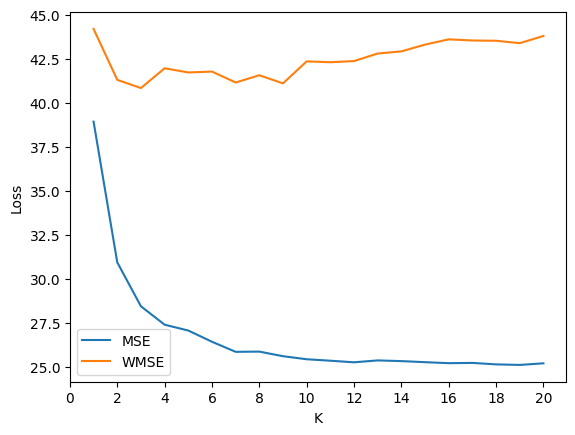

In [15]:
plt.plot(range(1, 21), mses, label="MSE")
plt.plot(range(1, 21), wmses, label="WMSE")
plt.legend()
plt.xlabel("K")
plt.xticks(range(0, 21, 2))
plt.ylabel("Loss");

# Final Model
* Train with all data between 1/1/2022 and 1/14/2024
* Test with data between 1/15/2024 and 3/22/2024

In [18]:
models = {}


for t in [0, 4, 8, 12, 16, 20]:
    for w in [0, 1]:
        knn_regressor = KNeighborsRegressor(n_neighbors=7, weights='distance')
        mask = (X_trainval['time'] == t) & (X_trainval['workday'] == w)
        X_input = X_trainval[mask]['power']  
        y_input = y_trainval[mask]['power']  
        X_input = np.array([i for i in X_input])
        y_input = np.array([i for i in y_input])
        knn_regressor.fit(X_input, y_input)
        models[(t, w)] = knn_regressor

In [19]:
forecasts = []
for index, row in X_test.iterrows():
    forecasts.append(models[(row['time'], row['workday'])].predict(np.array(row['power']).reshape(1, -1)))

forecast = np.array([f[0] for f in forecasts]).flatten()
real = np.array([a for a in y_test['power'].to_numpy()]).flatten()

mse = mean_squared_error(forecast, real)

weights = alpha ** (1 + np.sign(forecast - real))
wmse = mean_squared_error(forecast, real, sample_weight=weights)

print(f"MSE={mse}\tWMSE={wmse}")

MSE=32.92960316971539	WMSE=51.294079669685864


# Sanity Check

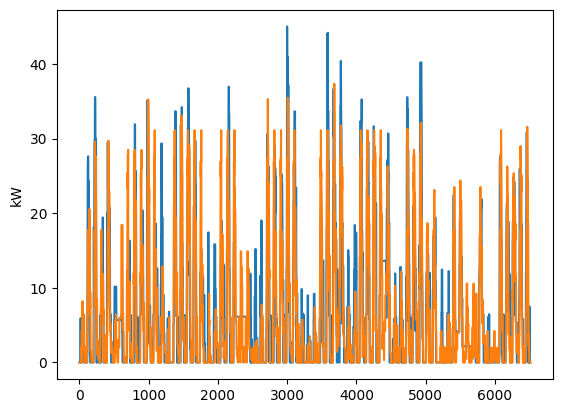

In [13]:
all_forecast = np.array([f[0] for f in forecasts]).flatten()
all_real = np.array([a for a in y_test['power'].to_numpy()]).flatten()

plt.plot(real, label="Actual")
plt.plot(forecast, label="Forecast")
plt.ylabel("kW");